In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
aapl = pd.read_csv("/content/AAPL_raw.csv")
msft = pd.read_csv("/content/MSFT_raw.csv")
goog = pd.read_csv("/content/GOOG_raw.csv")

In [38]:
mutual = pd.read_csv("/content/comprehensive_mutual_funds_data.csv")

In [41]:
aapl.columns = aapl.columns.str.strip().str.lower()
msft.columns = msft.columns.str.strip().str.lower()
goog.columns = goog.columns.str.strip().str.lower()
mutual.columns = mutual.columns.str.strip().str.lower()

aapl.rename(columns={'close/last': 'close'}, inplace=True)

In [42]:
aapl['close'] = aapl['close'].astype(str).str.replace('$','', regex=False)
aapl['close'] = pd.to_numeric(aapl['close'], errors='coerce')
aapl = aapl.dropna(subset=['close'])

In [43]:
msft['close'] = pd.to_numeric(msft['close'], errors='coerce')
goog['close'] = pd.to_numeric(goog['close'], errors='coerce')

In [44]:
aapl['date'] = pd.to_datetime(aapl['date'])
msft['date'] = pd.to_datetime(msft['date'])
goog['date'] = pd.to_datetime(goog['date'])

In [45]:
aapl = aapl.sort_values('date')
msft = msft.sort_values('date')
goog = goog.sort_values('date')

In [46]:
aapl['daily_return'] = aapl['close'].pct_change()
msft['daily_return'] = msft['close'].pct_change()
goog['daily_return'] = goog['close'].pct_change()

/tmp/ipykernel_287/1139415497.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
 goog['daily_return'] = goog['close'].pct_change()


In [56]:
aapl = aapl.dropna(subset=['close'])
msft = msft.dropna(subset=['close'])
goog = goog.dropna(subset=['close'])

In [59]:
start_date = "2010-01-01"

aapl_recent = aapl[aapl['date'] >= start_date]
msft_recent = msft[msft['date'] >= start_date]
goog_recent = goog[goog['date'] >= start_date]

In [60]:
aapl_norm = aapl_recent['close'] / aapl_recent['close'].iloc[0] * 100
msft_norm = msft_recent['close'] / msft_recent['close'].iloc[0] * 100
goog_norm = goog_recent['close'] / goog_recent['close'].iloc[0] * 100

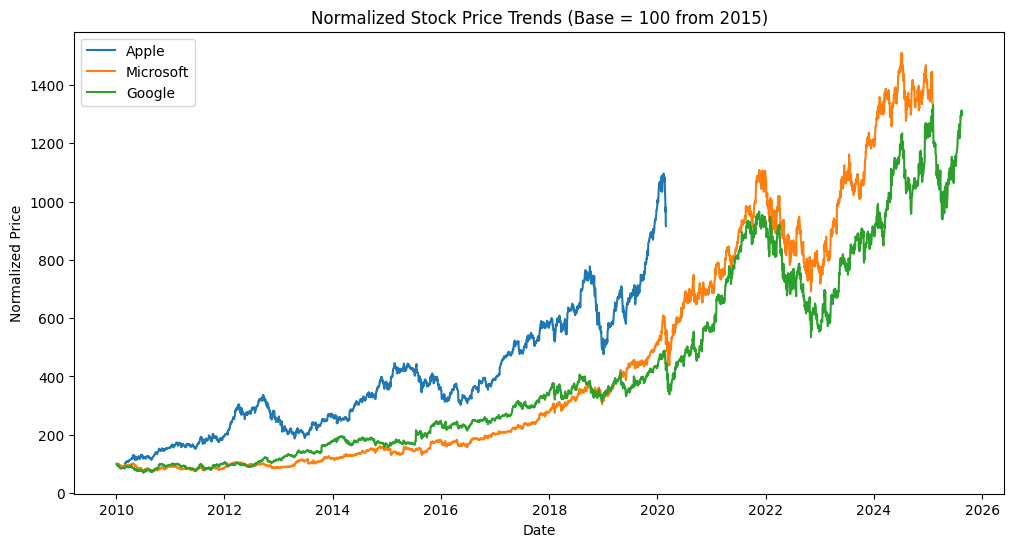

In [61]:
plt.figure(figsize=(12,6))

plt.plot(aapl_recent['date'], aapl_norm, label="Apple")
plt.plot(msft_recent['date'], msft_norm, label="Microsoft")
plt.plot(goog_recent['date'], goog_norm, label="Google")

plt.title("Normalized Stock Price Trends (Base = 100 from 2015)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()
plt.show()

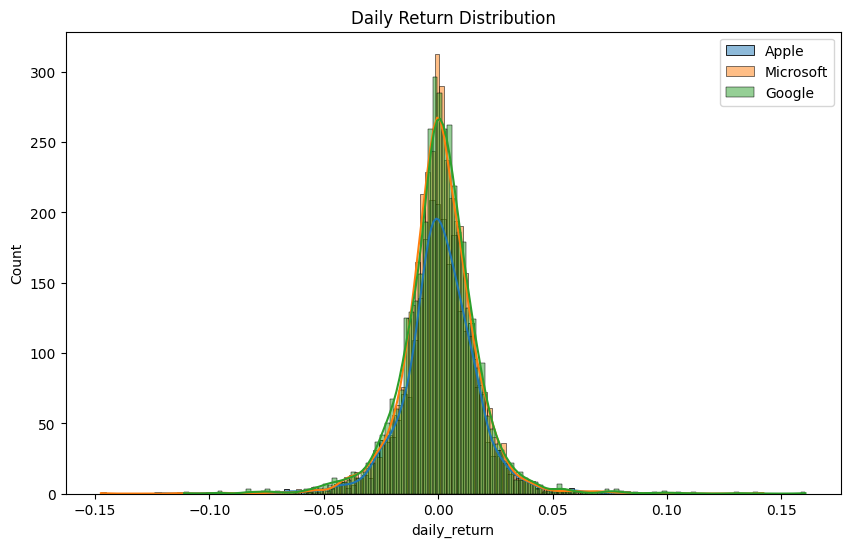

In [63]:
plt.figure(figsize=(10,6))

sns.histplot(aapl_recent['daily_return'], label="Apple", kde=True)
sns.histplot(msft_recent['daily_return'], label="Microsoft", kde=True)
sns.histplot(goog_recent['daily_return'], label="Google", kde=True)

plt.title("Daily Return Distribution")
plt.legend()

plt.show()

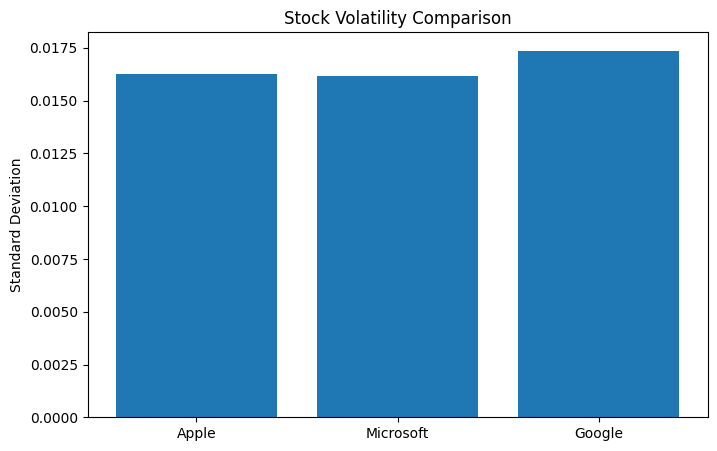

In [64]:
volatility = {
 "Apple": aapl_recent['daily_return'].std(),
 "Microsoft": msft_recent['daily_return'].std(),
 "Google": goog_recent['daily_return'].std()
}

plt.figure(figsize=(8,5))

plt.bar(volatility.keys(), volatility.values())

plt.title("Stock Volatility Comparison")
plt.ylabel("Standard Deviation")

plt.show()

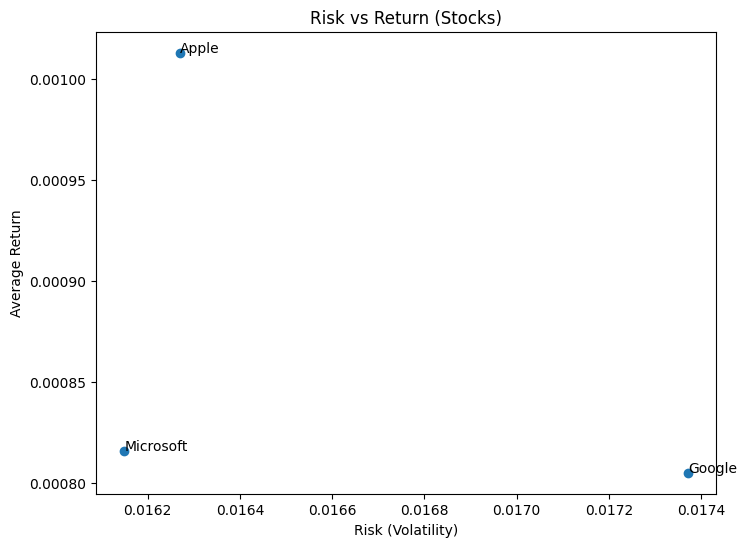

In [65]:
returns = {
 "Apple": aapl_recent['daily_return'].mean(),
 "Microsoft": msft_recent['daily_return'].mean(),
 "Google": goog_recent['daily_return'].mean()
}

plt.figure(figsize=(8,6))

plt.scatter(volatility.values(), returns.values())

for i, stock in enumerate(returns.keys()):
 plt.text(list(volatility.values())[i], list(returns.values())[i], stock)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Average Return")
plt.title("Risk vs Return (Stocks)")

plt.show()

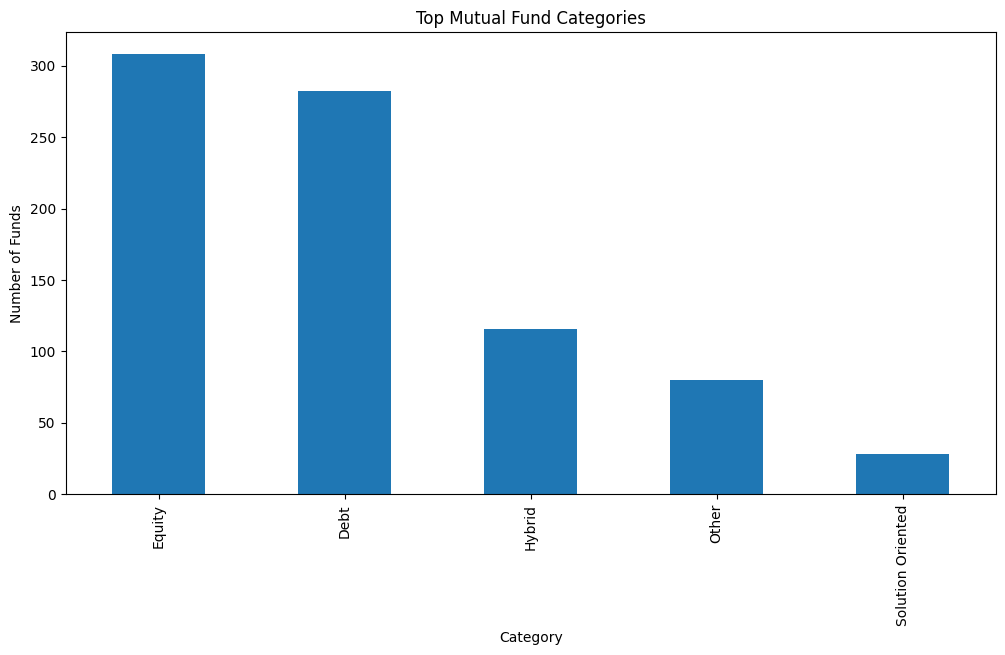

In [66]:
plt.figure(figsize=(12,6))

mutual['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top Mutual Fund Categories")
plt.xlabel("Category")
plt.ylabel("Number of Funds")

plt.show()

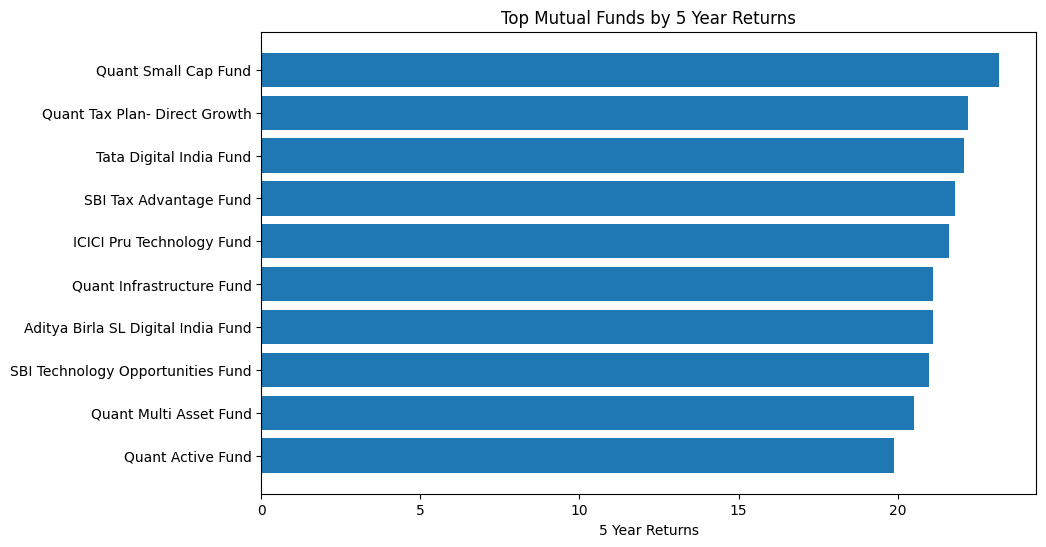

In [67]:
top_funds = mutual.sort_values('returns_5yr', ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top_funds['scheme_name'], top_funds['returns_5yr'])

plt.xlabel("5 Year Returns")
plt.title("Top Mutual Funds by 5 Year Returns")

plt.gca().invert_yaxis()

plt.show()

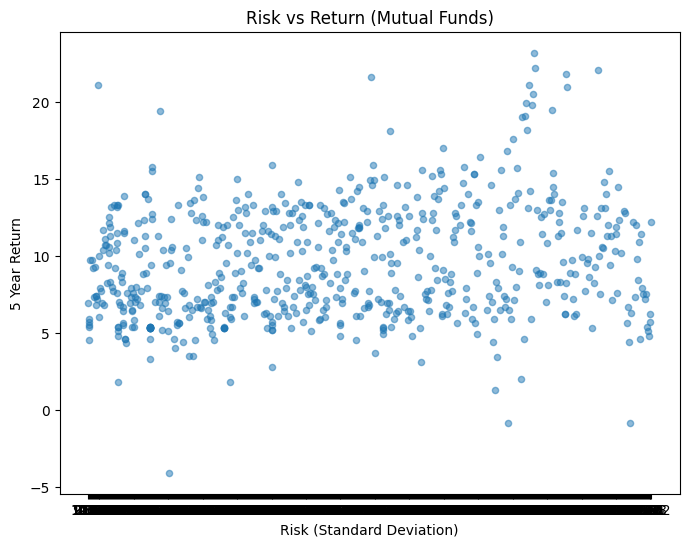

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(mutual['sd'], mutual['returns_5yr'], alpha=0.5, s=20)

plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("5 Year Return")
plt.title("Risk vs Return (Mutual Funds)")

plt.show()